# 🥇 Gold Futures — Dynamic Regime-KNN & CVaR-Constrained SLSQP Portfolio Engine

Adaptation of the KNN macro-regime / Bellman utility / CVaR-SLSQP architecture to a single-instrument
(COMEX Gold, `GC=F`) context.

Since gold is one instrument rather than a 50-stock universe, the "assets" being allocated across are
a bank of **systematic gold sub-strategies** (trend, momentum, mean-reversion, breakout, vol-targeting,
real-yield/DXY macro overlays). The engine:

1. Builds a macro feature matrix (VIX, DXY momentum, real-yield change, credit spread, realized vol, breadth)
2. Uses **K-Nearest-Neighbours (K=60)** with a softmax kernel to match the current macro state to historical
   analog regimes, producing a **time-varying risk-aversion (λₜ)** and **CVaR penalty (κₜ)**
3. Formulates a **Bellman-style one-step utility**: `U(w) = w'μ − (λ/2)·w'Σw − κ·CVaR₀.₀₅(w)`
4. Optimizes strategy weights via **scipy SLSQP** under long-only, bounded, fully-invested constraints
5. Runs a **Monte Carlo sweep** over random strategy subsets + regime-parameter draws to build a universe
   of candidate portfolios, then ranks them by realized utility
6. Renders the same 4-panel dashboard (risk/return, top-5 equity curves, drawdown distribution,
   utility-vs-Sharpe) against a **buy-and-hold gold benchmark**

Data source: `yfinance` (free). No paid data subscriptions required.

> ⚠️ This is a research/backtesting engine, not investment advice. All signals are in-sample-fit on
> historical data and are subject to survivorship, look-ahead, and regime-change risk — validate out-of-sample
> and on your funded-account execution venue (Quantower) before risking capital.


In [1]:
# ============================================================
# 0. CONFIG & IMPORTS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import zscore
from sklearn.neighbors import NearestNeighbors
from datetime import datetime

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(42)

CONFIG = {
    "start_date": "2010-01-01",
    "end_date": datetime.today().strftime("%Y-%m-%d"),
    "gold_ticker": "GC=F",
    "macro_tickers": {
        "dxy": "DX-Y.NYB",     # ICE US Dollar Index (fallback: 'UUP')
        "tnx": "^TNX",         # CBOE 10Y Treasury yield index (x10)
        "vix": "^VIX",         # CBOE Volatility Index
        "silver": "SI=F",      # COMEX Silver Futures
        "hyg": "HYG",          # High-yield credit ETF
        "ief": "IEF",          # 7-10Y Treasury ETF (rate proxy)
        "tip": "TIP",          # TIPS ETF (real-yield proxy vs IEF)
    },
    "knn_k": 60,                 # neighbours for regime matching
    "feature_weights": {         # relative importance in KNN distance
        "vix": 1.4, "dxy_mom": 1.0, "real_yield_chg": 1.3,
        "credit_spread": 0.8, "gold_rv": 1.0, "breadth": 0.9,
    },
    "cvar_alpha": 0.05,           # tail probability for CVaR
    "lambda_range": (1.5, 5.0),   # risk-aversion sampling range (Monte Carlo)
    "kappa_range": (0.5, 3.0),    # CVaR-penalty sampling range (Monte Carlo)
    "weight_bounds": (0.0, 0.6),  # per-strategy weight cap (diversification)
    "mc_trials": 4000,            # Monte Carlo candidate portfolios
    "min_strategies": 3,          # min sleeves per candidate portfolio
    "trading_days": 252,
    "risk_free": 0.0,
}
print(f"Config loaded. Window: {CONFIG['start_date']} -> {CONFIG['end_date']}")


Config loaded. Window: 2010-01-01 -> 2026-09-17


In [2]:
# ============================================================
# 1. DATA ACQUISITION — GOLD FUTURES + MACRO DRIVERS (yfinance, free)
# ============================================================

def fetch_close(ticker, start, end, fallback=None):
    """Robust single-ticker Close fetch, handling yfinance's occasional
    MultiIndex columns and empty/failed pulls with an optional fallback ticker."""
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        s = df["Close"].dropna()
        if s.empty and fallback:
            return fetch_close(fallback, start, end)
        s.name = ticker
        return s
    except Exception as e:
        if fallback:
            print(f"  {ticker} failed ({e}); falling back to {fallback}")
            return fetch_close(fallback, start, end)
        raise

print("Downloading GC=F (COMEX Gold Futures)...")
gold = fetch_close(CONFIG["gold_ticker"], CONFIG["start_date"], CONFIG["end_date"])

print("Downloading macro drivers...")
mt = CONFIG["macro_tickers"]
dxy    = fetch_close(mt["dxy"], CONFIG["start_date"], CONFIG["end_date"], fallback="UUP")
tnx    = fetch_close(mt["tnx"], CONFIG["start_date"], CONFIG["end_date"])
vix    = fetch_close(mt["vix"], CONFIG["start_date"], CONFIG["end_date"])
silver = fetch_close(mt["silver"], CONFIG["start_date"], CONFIG["end_date"])
hyg    = fetch_close(mt["hyg"], CONFIG["start_date"], CONFIG["end_date"])
ief    = fetch_close(mt["ief"], CONFIG["start_date"], CONFIG["end_date"])
tip    = fetch_close(mt["tip"], CONFIG["start_date"], CONFIG["end_date"])

px = pd.concat(
    [gold.rename("gold"), dxy.rename("dxy"), tnx.rename("tnx"), vix.rename("vix"),
     silver.rename("silver"), hyg.rename("hyg"), ief.rename("ief"), tip.rename("tip")],
    axis=1
).ffill().dropna()

ret = px["gold"].pct_change().fillna(0)

print(f"Data loaded: {px.index.min().date()} -> {px.index.max().date()}  ({len(px)} trading days)")
px.tail()


Data loaded: 2010-01-04 -> 2026-09-16  (4208 trading days)


,gold,dxy,tnx,vix,silver,hyg,ief,tip
Date,,,,,,,,
2026-09-10,"4,407.2998",99.0900,4.9440,17.8400,64.2840,78.6200,91.1800,106.3300
2026-09-11,"4,408.8999",99.1200,4.9750,15.8400,64.5540,78.6000,91.0100,105.8400
2026-09-14,"4,351.8999",99.4600,4.9610,17.1000,63.5130,78.5300,90.9300,105.8200
2026-09-15,"4,332.7998",99.6500,4.9960,17.2000,63.2360,78.3800,90.8200,105.7900
2026-09-16,"4,387.5000",100.3100,5.0060,17.7100,64.2880,78.4200,90.7300,105.3900


In [3]:
# ============================================================
# 2. STRATEGY SLEEVES — the "assets" the optimizer allocates across
#    (single-instrument analogue of the SET50 stock universe)
# ============================================================

def ema(s, span):
    return s.ewm(span=span, adjust=False).mean()

def rsi(s, n=2):
    d = s.diff()
    up = d.clip(lower=0).rolling(n).mean()
    dn = (-d.clip(upper=0)).rolling(n).mean()
    rs = up / dn.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

g = px["gold"]
strat = pd.DataFrame(index=px.index)

# --- Trend: EMA20/EMA100 crossover -------------------------------------
trend_sig = np.sign(ema(g, 20) - ema(g, 100))
strat["trend_ema"] = trend_sig.shift(1) * ret

# --- Momentum: 60d return, skip most-recent 5d (12-1 style) ------------
mom = g.pct_change(60).shift(5)
strat["mom_12_1"] = np.sign(mom).shift(1) * ret

# --- Mean reversion: RSI(2) extremes ------------------------------------
r2 = rsi(g, 2)
mr_sig = pd.Series(0.0, index=px.index)
mr_sig[r2 < 10] = 1.0
mr_sig[r2 > 90] = -1.0
strat["mean_rev_rsi2"] = mr_sig.shift(1) * ret

# --- Breakout: Donchian(20) channel -------------------------------------
hh, ll = g.rolling(20).max(), g.rolling(20).min()
brk_sig = pd.Series(0.0, index=px.index)
brk_sig[g >= hh.shift(1)] = 1.0
brk_sig[g <= ll.shift(1)] = -1.0
strat["breakout_donchian"] = brk_sig.shift(1) * ret

# --- Vol-targeted trend: EMA trend scaled to 15% annualized vol --------
rv20 = ret.rolling(20).std() * np.sqrt(CONFIG["trading_days"])
voltarget_scale = (0.15 / rv20).clip(upper=3).fillna(0)
strat["voltarget_trend"] = (trend_sig.shift(1) * voltarget_scale.shift(1)) * ret

# --- Real-yield macro overlay: short gold when 10Y yield rising fast ---
dtnx10 = px["tnx"].diff(10)
strat["real_yield_signal"] = (-np.sign(dtnx10)).shift(1) * ret

# --- DXY macro overlay: short gold when USD strengthening fast ---------
ddxy10 = px["dxy"].pct_change(10)
strat["dxy_inverse"] = (-np.sign(ddxy10)).shift(1) * ret

# --- Long-term regime filter: price vs 200D MA -------------------------
regime200 = np.sign(g - g.rolling(200).mean())
strat["ma200_filter"] = regime200.shift(1) * ret

strat = strat.fillna(0)
strategy_names = list(strat.columns)
print(f"{len(strategy_names)} strategy sleeves built: {strategy_names}")
strat.describe().T[["mean", "std", "min", "max"]]


8 strategy sleeves built: ['trend_ema', 'mom_12_1', 'mean_rev_rsi2', 'breakout_donchian', 'voltarget_trend', 'real_yield_signal', 'dxy_inverse', 'ma200_filter']


,mean,std,min,max
trend_ema,0.0002,0.0108,-0.1078,0.0935
mom_12_1,0.0001,0.0107,-0.1078,0.0935
mean_rev_rsi2,0.0001,0.0064,-0.0935,0.0607
breakout_donchian,-0.0000,0.0058,-0.1078,0.0935
voltarget_trend,0.0003,0.0105,-0.0674,0.0726
real_yield_signal,0.0002,0.0108,-0.0935,0.1078
dxy_inverse,-0.0002,0.0108,-0.1078,0.0607
ma200_filter,0.0001,0.0106,-0.1078,0.0935


Regime-matched 4109 days against 60-neighbour macro analogs.
Dynamic risk-aversion (lambda_t): 1.50 - 5.00
Dynamic CVaR penalty   (kappa_t): 0.50 - 3.00


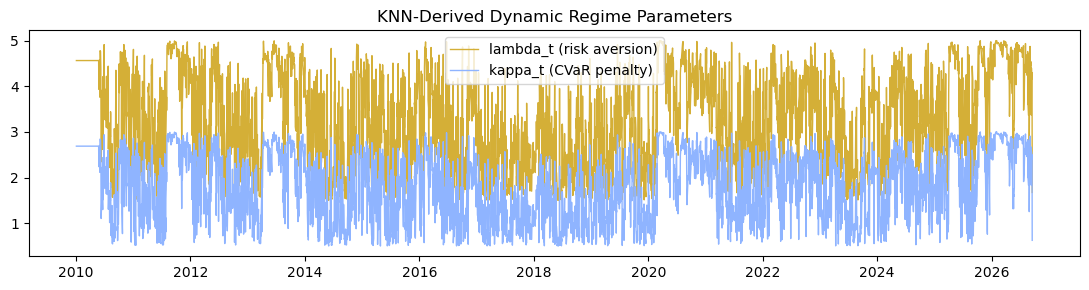

In [4]:
# ============================================================
# 3. MACRO FEATURE MATRIX + KNN REGIME MATCHING (K=60, softmax kernel)
# ============================================================
feat = pd.DataFrame(index=px.index)
feat["vix"]            = px["vix"]
feat["dxy_mom"]         = px["dxy"].pct_change(20)
feat["real_yield_chg"]  = px["tnx"].diff(20)
feat["credit_spread"]   = (px["hyg"] / px["ief"]).pct_change(20)
feat["gold_rv"]         = ret.rolling(20).std() * np.sqrt(CONFIG["trading_days"])
feat["breadth"]         = g / g.rolling(100).mean() - 1
feat = feat.dropna()

Z = feat.apply(zscore)
fw = np.array([CONFIG["feature_weights"][c] for c in feat.columns])
Zw = Z.values * fw

K = CONFIG["knn_k"]
nn = NearestNeighbors(n_neighbors=K).fit(Zw)
dist, idx = nn.kneighbors(Zw)

# Softmax-style exponential kernel on neighbour distances
kern = np.exp(-dist / (dist.std(axis=1, keepdims=True) + 1e-9))
kern = kern / kern.sum(axis=1, keepdims=True)

fwd_ret = ret.reindex(feat.index).shift(-1).fillna(0).values
analog_ret = np.zeros(len(feat))
analog_vol = np.zeros(len(feat))
for i in range(len(feat)):
    nf = fwd_ret[idx[i]]
    analog_ret[i] = np.average(nf, weights=kern[i])
    analog_vol[i] = np.sqrt(np.average((nf - analog_ret[i]) ** 2, weights=kern[i]))

analog_ret = pd.Series(analog_ret, index=feat.index, name="knn_analog_ret")
analog_vol = pd.Series(analog_vol, index=feat.index, name="knn_analog_vol")

# Regime "stress" percentile -> dynamic risk-aversion (lambda) & CVaR penalty (kappa)
stress = analog_vol.rank(pct=True)
lo, hi = CONFIG["lambda_range"]
lam_t = (lo + (hi - lo) * stress).reindex(px.index).ffill().bfill()
lo, hi = CONFIG["kappa_range"]
kap_t = (lo + (hi - lo) * stress).reindex(px.index).ffill().bfill()

print(f"Regime-matched {len(feat)} days against {K}-neighbour macro analogs.")
print(f"Dynamic risk-aversion (lambda_t): {lam_t.min():.2f} - {lam_t.max():.2f}")
print(f"Dynamic CVaR penalty   (kappa_t): {kap_t.min():.2f} - {kap_t.max():.2f}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(lam_t.index, lam_t, color="#d4af37", lw=1, label="lambda_t (risk aversion)")
ax.plot(kap_t.index, kap_t, color="#8fb4ff", lw=1, label="kappa_t (CVaR penalty)")
ax.set_title("KNN-Derived Dynamic Regime Parameters")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# ============================================================
# 4. BELLMAN-STYLE CVaR-PENALIZED UTILITY + SLSQP SOLVER
#    U(w) = w'mu - (lambda/2)*w'Sigma*w - kappa * CVaR_alpha(w)
# ============================================================
ALPHA = CONFIG["cvar_alpha"]

def portfolio_cvar(weights, R, alpha=ALPHA):
    """Historical (non-parametric) CVaR of the weighted return series."""
    port = R @ weights
    var_cut = np.percentile(port, alpha * 100)
    tail = port[port <= var_cut]
    return -tail.mean() if len(tail) else 0.0

def neg_bellman_utility(w, mu, Sigma, R, lam, kap):
    ret_term  = w @ mu
    risk_term = 0.5 * lam * (w @ Sigma @ w)
    cvar_term = kap * portfolio_cvar(w, R)
    return -(ret_term - risk_term - cvar_term)

def solve_slsqp(mu, Sigma, R, lam, kap, bounds, n_assets, x0=None):
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    x0 = x0 if x0 is not None else np.ones(n_assets) / n_assets
    res = minimize(
        neg_bellman_utility, x0, args=(mu, Sigma, R, lam, kap),
        method="SLSQP", bounds=bounds, constraints=cons,
        options={"maxiter": 300, "ftol": 1e-9},
    )
    return res

# Full-universe reference solve at mean regime parameters
R_full = strat.values
mu_full = R_full.mean(axis=0) * CONFIG["trading_days"]
Sigma_full = np.cov(R_full.T) * CONFIG["trading_days"]
n_assets = R_full.shape[1]
bnds_full = [CONFIG["weight_bounds"]] * n_assets

ref = solve_slsqp(mu_full, Sigma_full, R_full, lam_t.mean(), kap_t.mean(), bnds_full, n_assets)
print("Reference full-universe SLSQP solve (mean regime params):")
for name, w in zip(strategy_names, ref.x):
    print(f"  {name:20s} {w:6.3f}")
print(f"  converged: {ref.success}   utility: {-ref.fun:.5f}")


Reference full-universe SLSQP solve (mean regime params):
  trend_ema             0.000
  mom_12_1              0.000
  mean_rev_rsi2         0.408
  breakout_donchian     0.000
  voltarget_trend       0.366
  real_yield_signal     0.227
  dxy_inverse           0.000
  ma200_filter          0.000
  converged: True   utility: 0.00836


In [6]:
# ============================================================
# 5. MONTE CARLO SWEEP — random strategy subsets x regime params -> SLSQP
#    Builds the candidate-portfolio universe (mirrors the stock-combo sweep
#    in the original SET50 dashboard, here over strategy-sleeve combos)
# ============================================================
rng = np.random.default_rng(7)
lam_lo, lam_hi = CONFIG["lambda_range"]
kap_lo, kap_hi = CONFIG["kappa_range"]
wb = CONFIG["weight_bounds"]
n_trials = CONFIG["mc_trials"]
min_k = CONFIG["min_strategies"]

results = []
for trial in range(n_trials):
    k = rng.integers(min_k, n_assets + 1)
    subset = rng.choice(n_assets, size=k, replace=False)
    Rs = R_full[:, subset]
    mus = mu_full[subset]
    Sigs = Sigma_full[np.ix_(subset, subset)]

    lam_i = rng.uniform(lam_lo, lam_hi)
    kap_i = rng.uniform(kap_lo, kap_hi)

    res = solve_slsqp(mus, Sigs, Rs, lam_i, kap_i, [wb] * k, k)
    if not res.success:
        continue

    w = res.x
    port_ret = Rs @ w
    equity = (1 + port_ret).cumprod()
    n_years = len(port_ret) / CONFIG["trading_days"]
    cagr = equity[-1] ** (1 / n_years) - 1 if n_years > 0 else 0.0
    vol = port_ret.std() * np.sqrt(CONFIG["trading_days"])
    sharpe = (port_ret.mean() * CONFIG["trading_days"] - CONFIG["risk_free"]) / (vol + 1e-9)
    max_dd = (equity / np.maximum.accumulate(equity) - 1).min()

    results.append(dict(
        cagr=cagr, vol=vol, sharpe=sharpe, maxdd=max_dd, utility=-res.fun,
        n_strats=k, subset=subset, weights=w, lam=lam_i, kap=kap_i,
    ))

res_df = pd.DataFrame(results)
print(f"{len(res_df)}/{n_trials} candidate portfolios converged.")
res_df[["cagr", "vol", "sharpe", "maxdd", "utility"]].describe()


4000/4000 candidate portfolios converged.


,cagr,vol,sharpe,maxdd,utility
count,"4,000.0000","4,000.0000","4,000.0000","4,000.0000","4,000.0000"
mean,0.0362,0.0951,0.4292,-0.2168,-0.0004
std,0.0101,0.0217,0.0925,0.0606,0.0167
min,-0.0008,0.0554,0.0389,-0.5569,-0.0850
25%,0.0303,0.0811,0.3771,-0.2466,-0.0088
50%,0.0375,0.0919,0.4520,-0.2033,0.0004
75%,0.0433,0.1078,0.5092,-0.1774,0.0110
max,0.0524,0.1661,0.5196,-0.1255,0.0362


In [10]:
# ============================================================
# 6. RANK BY UTILITY + BUY-AND-HOLD GOLD BENCHMARK
# ============================================================
res_df = res_df.sort_values("utility", ascending=False).reset_index(drop=True)
top5 = res_df.head(5).copy()
rank1 = res_df.iloc[0]

bench_equity = (1 + ret).cumprod()
bench_years = len(ret) / CONFIG["trading_days"]
bench_cagr = bench_equity.iloc[-1] ** (1 / bench_years) - 1
bench_vol = ret.std() * np.sqrt(CONFIG["trading_days"])
bench_sharpe = (ret.mean() * CONFIG["trading_days"]) / (bench_vol + 1e-9)
bench_dd = (bench_equity / bench_equity.cummax() - 1).min()

print(" BENCHMARK: Gold Futures Buy & Hold ")
print(f"  CAGR {bench_cagr*100:6.2f}%   Vol {bench_vol*100:6.2f}%   "
      f"Sharpe {bench_sharpe:5.2f}   MaxDD {bench_dd*100:6.2f}%")

print("\n TOP 5 UTILITY PORTFOLIOS ")
for i, row in top5.iterrows():
    names = [strategy_names[j] for j in row.subset]
    weights_str = ", ".join(f"{n}={w:.2f}" for n, w in zip(names, row.weights) if w > 0.01)
    print(f"\nRank #{i+1}  |  Utility {row.utility:.4f}  |  CAGR {row.cagr*100:5.2f}%  "
          f"Vol {row.vol*100:5.2f}%  Sharpe {row.sharpe:5.2f}  MaxDD {row.maxdd*100:6.2f}%")
    print(f"  Weights: {weights_str}")


 BENCHMARK: Gold Futures Buy & Hold 
  CAGR   8.53%   Vol  17.19%   Sharpe  0.56   MaxDD -44.36%

 TOP 5 UTILITY PORTFOLIOS 

Rank #1  |  Utility 0.0362  |  CAGR  5.13%  Vol 11.95%  Sharpe  0.48  MaxDD -25.28%
  Weights: mean_rev_rsi2=0.08, real_yield_signal=0.32, voltarget_trend=0.60

Rank #2  |  Utility 0.0361  |  CAGR  5.24%  Vol 12.65%  Sharpe  0.47  MaxDD -25.49%
  Weights: real_yield_signal=0.40, voltarget_trend=0.60

Rank #3  |  Utility 0.0360  |  CAGR  5.13%  Vol 11.92%  Sharpe  0.48  MaxDD -25.30%
  Weights: mean_rev_rsi2=0.08, voltarget_trend=0.60, real_yield_signal=0.32

Rank #4  |  Utility 0.0358  |  CAGR  5.12%  Vol 11.90%  Sharpe  0.48  MaxDD -25.32%
  Weights: mean_rev_rsi2=0.08, real_yield_signal=0.32, voltarget_trend=0.60

Rank #5  |  Utility 0.0354  |  CAGR  5.12%  Vol 11.87%  Sharpe  0.48  MaxDD -25.35%
  Weights: real_yield_signal=0.32, mean_rev_rsi2=0.08, voltarget_trend=0.60


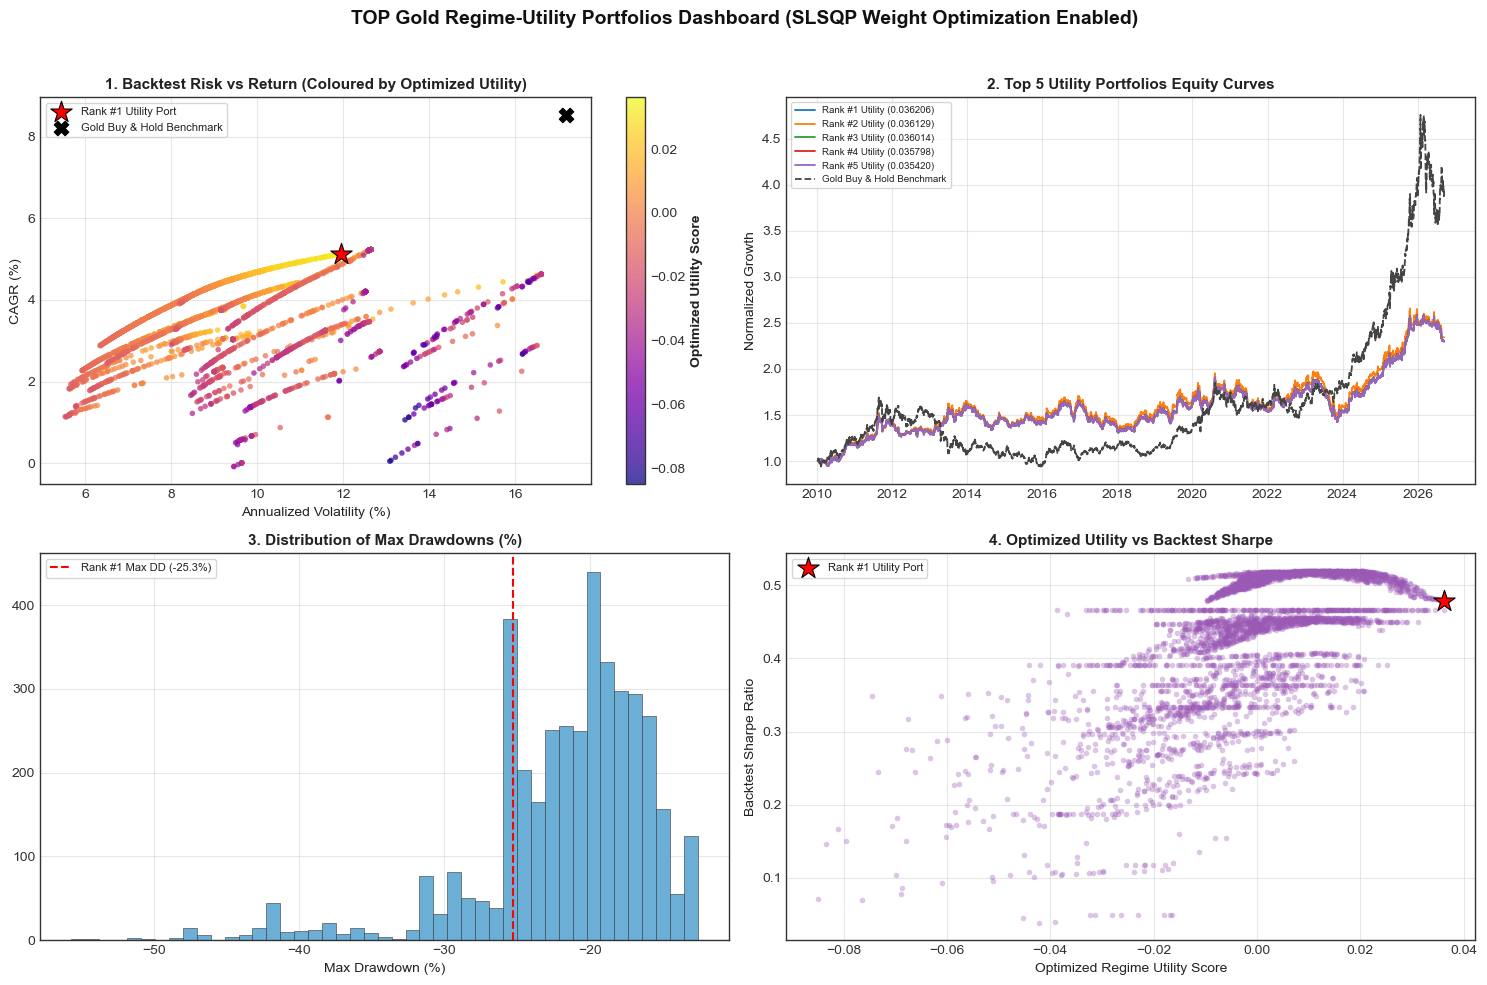

In [8]:
# ============================================================
# 7. DASHBOARD — light seaborn-whitegrid theme (matches reference layout)
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#333333", "axes.labelcolor": "#222222",
    "text.color": "#222222", "xtick.color": "#333333", "ytick.color": "#333333",
    "grid.color": "#dddddd", "grid.alpha": 0.7, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold",
})
TAB10 = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("TOP Gold Regime-Utility Portfolios Dashboard (SLSQP Weight Optimization Enabled)",
             fontsize=14, color="#111111", fontweight="bold", y=0.98)

# --- Panel 1: Risk vs Return, colored by utility ------------------------
ax = axes[0, 0]
sc = ax.scatter(res_df.vol * 100, res_df.cagr * 100, c=res_df.utility,
                 cmap="plasma", s=16, alpha=0.75, linewidths=0)
ax.scatter(rank1.vol * 100, rank1.cagr * 100, marker="*", s=260, c="red",
           edgecolor="black", linewidth=0.8, label="Rank #1 Utility Port", zorder=5)
ax.scatter(bench_vol * 100, bench_cagr * 100, marker="X", s=110, c="black",
           edgecolor="black", linewidth=0.8, label="Gold Buy & Hold Benchmark", zorder=5)
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("CAGR (%)")
ax.set_title("1. Backtest Risk vs Return (Coloured by Optimized Utility)")
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=8)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Optimized Utility Score", color="#222222", fontweight="bold")

# --- Panel 2: Top 5 equity curves ---------------------------------------
ax = axes[0, 1]
for i, (_, row) in enumerate(top5.iterrows()):
    Rs = R_full[:, row.subset]
    eq = (1 + Rs @ row.weights).cumprod()
    ax.plot(strat.index, eq, label=f"Rank #{i+1} Utility ({row.utility:.6f})",
            color=TAB10[i], lw=1.3)
ax.plot(bench_equity.index, bench_equity.values, "--", color="#444444",
        label="Gold Buy & Hold Benchmark", lw=1.3)
ax.set_title("2. Top 5 Utility Portfolios Equity Curves")
ax.set_ylabel("Normalized Growth")
ax.legend(loc="upper left", fontsize=7, frameon=True, facecolor="white", edgecolor="#cccccc")

# --- Panel 3: Max drawdown distribution ---------------------------------
ax = axes[1, 0]
ax.hist(res_df.maxdd * 100, bins=45, color="#6baed6", edgecolor="#333333", linewidth=0.4)
ax.axvline(rank1.maxdd * 100, color="red", ls="--", lw=1.5,
           label=f"Rank #1 Max DD ({rank1.maxdd*100:.1f}%)")
ax.set_xlabel("Max Drawdown (%)")
ax.set_title("3. Distribution of Max Drawdowns (%)")
ax.legend(loc="upper left", fontsize=8, frameon=True, facecolor="white", edgecolor="#cccccc")

# --- Panel 4: Utility vs Sharpe ------------------------------------------
ax = axes[1, 1]
ax.scatter(res_df.utility, res_df.sharpe, c="#9b59b6", alpha=0.35, s=16, linewidths=0)
ax.scatter(rank1.utility, rank1.sharpe, marker="*", s=260, c="red",
           edgecolor="black", linewidth=0.8, label="Rank #1 Utility Port", zorder=5)
ax.set_xlabel("Optimized Regime Utility Score")
ax.set_ylabel("Backtest Sharpe Ratio")
ax.set_title("4. Optimized Utility vs Backtest Sharpe")
ax.legend(loc="upper left", fontsize=8, frameon=True, facecolor="white", edgecolor="#cccccc")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("gold_utility_dashboard.png", dpi=150, facecolor="white")
plt.show()


In [9]:
# ============================================================
# 8. EXPORT — Rank #1 portfolio weights + full candidate universe
# ============================================================
rank1_names = [strategy_names[j] for j in rank1.subset]
rank1_weights = pd.Series(rank1.weights, index=rank1_names, name="weight").sort_values(ascending=False)
rank1_weights.to_csv("gold_rank1_weights.csv")
print("Rank #1 portfolio weights (saved to gold_rank1_weights.csv):")
print(rank1_weights[rank1_weights > 0.001])

export_cols = ["cagr", "vol", "sharpe", "maxdd", "utility", "n_strats", "lam", "kap"]
res_df[export_cols].to_csv("gold_candidate_portfolios.csv", index_label="candidate_id")
print(f"\nFull candidate universe ({len(res_df)} portfolios) saved to gold_candidate_portfolios.csv")


Rank #1 portfolio weights (saved to gold_rank1_weights.csv):
voltarget_trend     0.6000
real_yield_signal   0.3240
mean_rev_rsi2       0.0760
Name: weight, dtype: float64

Full candidate universe (4000 portfolios) saved to gold_candidate_portfolios.csv
